# Energy Consumption Time Series Forecasting (Household Power Consumption)

## Problem Statement
Utilities and smart-home systems benefit from being able to forecast
short-term household energy usage. Using historical minute-level power
readings from a single household over ~4 years, this notebook resamples
the data to an hourly resolution, engineers time-based features, and
compares three forecasting approaches — ARIMA, Prophet, and XGBoost — to
predict future energy consumption.

## Objective
1. Parse and resample the raw time series data
2. Engineer time-based features (hour of day, weekday/weekend, etc.)
3. Compare ARIMA, Prophet, and XGBoost forecasting models
4. Plot actual vs. forecasted energy usage and evaluate with MAE / RMSE

## 1. Dataset Description & Loading

**Source:** Individual Household Electric Power Consumption Dataset (UCI Machine Learning Repository)
**Rows:** 2,075,259 minute-level measurements from a single household in Sceaux, France, December 2006 - November 2010 (47 months)

| Column | Description |
|---|---|
| Date / Time | Combined into a DateTime index |
| Global_active_power | Household global active power (kilowatts) — **our forecasting target** |
| Global_reactive_power | Household global reactive power (kilowatts) |
| Voltage | Minute-averaged voltage (volts) |
| Global_intensity | Minute-averaged current intensity (amperes) |
| Sub_metering_1/2/3 | Energy sub-metering for kitchen, laundry room, and water-heater/AC respectively |

We focus on **Global_active_power** as the forecasting target, since it represents overall household energy demand.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/household_power_consumption.zip'
df = pd.read_csv(url, sep=';', compression='zip', low_memory=False)
print("Raw shape:", df.shape)
df.head()

Raw shape: (2075259, 9)


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


## 2. Parsing & Cleaning

In [2]:
# Combine Date + Time into a single DateTime index
df['DateTime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H:%M:%S')
df = df.drop(columns=['Date', 'Time']).set_index('DateTime')

# All measurement columns were loaded as strings because missing values are marked '?'
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64


Missing values (~1.25% of rows, consistent with the dataset's known documentation)
are dropped, since they represent short gaps in metering rather than a
pattern we want to model or impute incorrectly.

In [3]:
df = df.dropna(subset=['Global_active_power'])
print("Shape after dropping missing target rows:", df.shape)
df[['Global_active_power']].describe()

Shape after dropping missing target rows: (2049280, 7)


,Global_active_power
count,2.049280e+06
mean,1.091615e+00
std,1.057294e+00
min,7.600000e-02
25%,3.080000e-01
50%,6.020000e-01
75%,1.528000e+00
max,1.112200e+01


## 3. Resampling to Hourly Frequency

The raw data is minute-level, which is far noisier and heavier than needed
for short-term forecasting. We resample to **hourly averages**, which
smooths minute-to-minute noise while preserving daily/weekly usage
patterns.

In [4]:
hourly = df['Global_active_power'].resample('h').mean()
print("Hourly series shape:", hourly.shape)
print("Missing hours after resampling:", hourly.isnull().sum())

# Interpolate the small number of gaps left after resampling
hourly = hourly.interpolate()
hourly.head()

Hourly series shape: (34589,)
Missing hours after resampling: 421


DateTime
2006-12-16 17:00:00    4.222889
2006-12-16 18:00:00    3.632200
2006-12-16 19:00:00    3.400233
2006-12-16 20:00:00    3.268567
2006-12-16 21:00:00    3.056467
Freq: h, Name: Global_active_power, dtype: float64

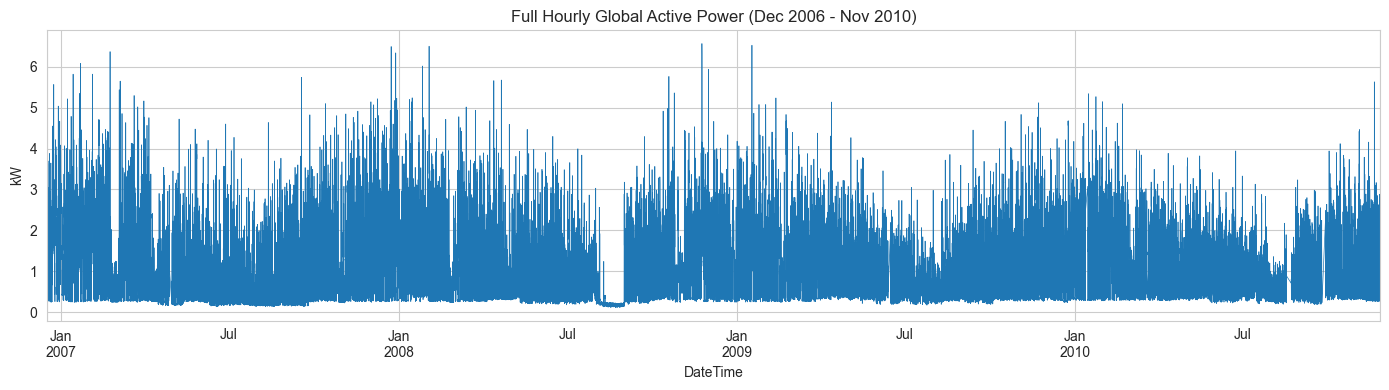

In [5]:
fig, ax = plt.subplots(figsize=(14, 4))
hourly.plot(ax=ax, linewidth=0.5)
ax.set_title('Full Hourly Global Active Power (Dec 2006 - Nov 2010)')
ax.set_ylabel('kW')
plt.tight_layout()
plt.show()

To keep training and forecasting fast while still capturing meaningful
daily/weekly seasonality, we focus modeling on the **most recent 60 days**
of hourly data (1,440 hours). This is a common, practical approach for
short-term forecasting — using the full 4-year history offers diminishing
returns for next-week predictions while significantly slowing training.

Recent subset shape: (1440,)
Date range: 2010-09-27 22:00:00 to 2010-11-26 21:00:00


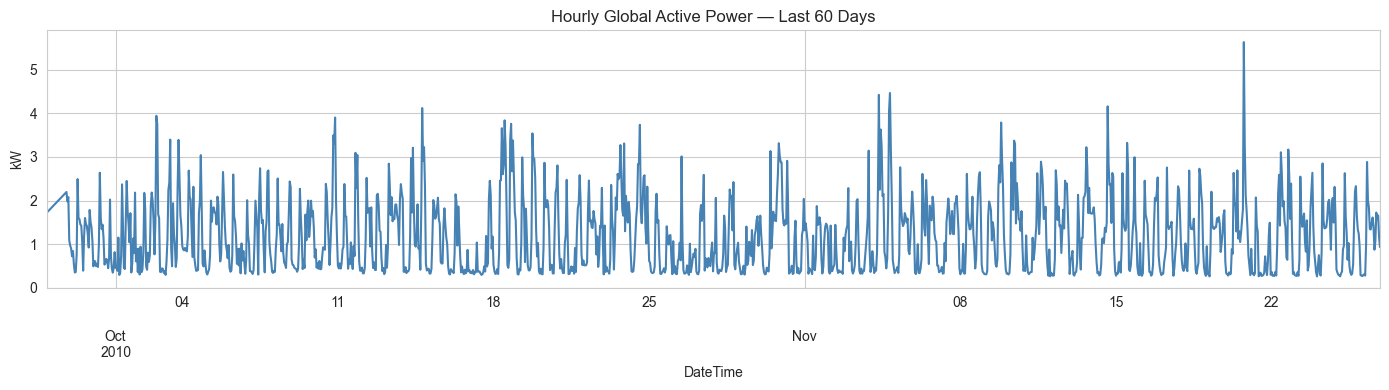

In [6]:
hourly_recent = hourly.iloc[-60*24:]
print("Recent subset shape:", hourly_recent.shape)
print("Date range:", hourly_recent.index.min(), "to", hourly_recent.index.max())

fig, ax = plt.subplots(figsize=(14, 4))
hourly_recent.plot(ax=ax, color='steelblue')
ax.set_title('Hourly Global Active Power — Last 60 Days')
ax.set_ylabel('kW')
plt.tight_layout()
plt.show()

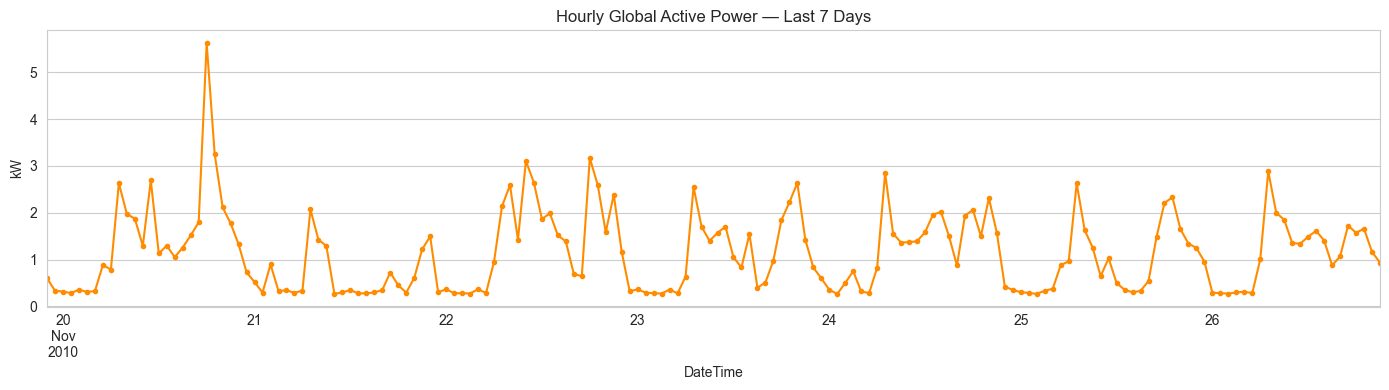

In [7]:
fig, ax = plt.subplots(figsize=(14, 4))
hourly_recent.iloc[-24*7:].plot(ax=ax, color='darkorange', marker='o', markersize=3)
ax.set_title('Hourly Global Active Power — Last 7 Days')
ax.set_ylabel('kW')
plt.tight_layout()
plt.show()

A clear **daily cycle** is visible — power usage rises in the morning,
dips mid-day, and peaks again in the evening, which is exactly the pattern
time-based features (hour of day, weekday/weekend) should help models
capture.

## 4. Feature Engineering

We engineer standard time-based features that let tree-based models like
XGBoost implicitly learn daily and weekly seasonality, since they don't
model time dependencies the way ARIMA or Prophet do natively.

In [8]:
feat_df = hourly_recent.to_frame('active_power')
feat_df['hour'] = feat_df.index.hour
feat_df['dayofweek'] = feat_df.index.dayofweek        # 0=Monday, 6=Sunday
feat_df['is_weekend'] = (feat_df['dayofweek'] >= 5).astype(int)
feat_df['day'] = feat_df.index.day
feat_df['month'] = feat_df.index.month

feat_df.head()

,active_power,hour,dayofweek,is_weekend,day,month
DateTime,,,,,,
2010-09-27 22:00:00,1.730117,22,0,0,27,9
2010-09-27 23:00:00,1.752349,23,0,0,27,9
2010-09-28 00:00:00,1.774580,0,1,0,28,9
2010-09-28 01:00:00,1.796812,1,1,0,28,9
2010-09-28 02:00:00,1.819043,2,1,0,28,9


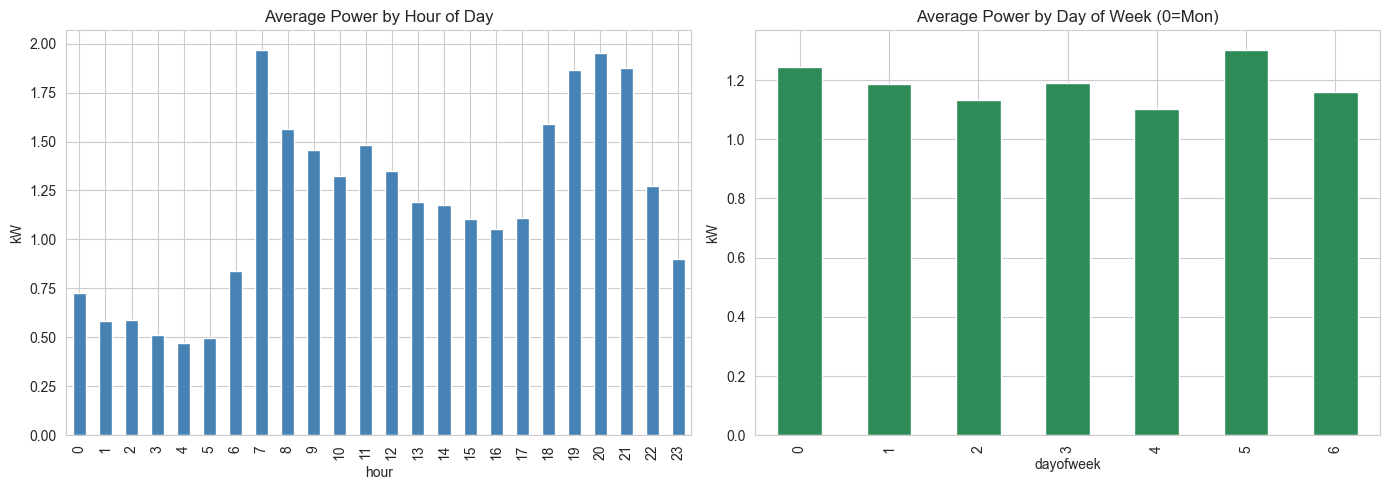

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

hourly_by_hour = feat_df.groupby('hour')['active_power'].mean()
hourly_by_hour.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Average Power by Hour of Day')
axes[0].set_ylabel('kW')

hourly_by_dow = feat_df.groupby('dayofweek')['active_power'].mean()
hourly_by_dow.plot(kind='bar', ax=axes[1], color='seagreen')
axes[1].set_title('Average Power by Day of Week (0=Mon)')
axes[1].set_ylabel('kW')

plt.tight_layout()
plt.show()

## 5. Train/Test Split

We hold out the **last 7 days (168 hours)** as a test set to evaluate
short-term forecasting performance, training on everything before that.

In [10]:
test_hours = 7 * 24
train = feat_df.iloc[:-test_hours]
test = feat_df.iloc[-test_hours:]

print("Train:", train.shape, "| Test:", test.shape)
print("Train range:", train.index.min(), "to", train.index.max())
print("Test range:", test.index.min(), "to", test.index.max())

Train: (1272, 6) | Test: (168, 6)
Train range: 2010-09-27 22:00:00 to 2010-11-19 21:00:00
Test range: 2010-11-19 22:00:00 to 2010-11-26 21:00:00


## 6. Model 1 — XGBoost

XGBoost treats this as a regression problem using the engineered time
features. It has no inherent notion of "time" — it purely learns patterns
from hour/day/weekend features.

In [11]:
import xgboost as xgb

feature_cols = ['hour', 'dayofweek', 'is_weekend', 'day', 'month']

model_xgb = xgb.XGBRegressor(n_estimators=200, max_depth=5, random_state=42)
model_xgb.fit(train[feature_cols], train['active_power'])

pred_xgb = model_xgb.predict(test[feature_cols])

mae_xgb = mean_absolute_error(test['active_power'], pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(test['active_power'], pred_xgb))
print(f"XGBoost — MAE: {mae_xgb:.4f} | RMSE: {rmse_xgb:.4f}")

XGBoost — MAE: 0.6358 | RMSE: 0.8649


## 7. Model 2 — ARIMA

ARIMA models the series purely from its own past values (autoregression),
differencing, and moving average terms — it doesn't use the engineered
time features directly, relying instead on the sequential structure of
the series itself.

In [12]:
from statsmodels.tsa.arima.model import ARIMA

model_arima = ARIMA(train['active_power'], order=(2, 1, 2))
fit_arima = model_arima.fit()

pred_arima = fit_arima.forecast(steps=test_hours)

mae_arima = mean_absolute_error(test['active_power'], pred_arima)
rmse_arima = np.sqrt(mean_squared_error(test['active_power'], pred_arima))
print(f"ARIMA — MAE: {mae_arima:.4f} | RMSE: {rmse_arima:.4f}")

C:\Users\FIREFLY LAPTOP'S\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


ARIMA — MAE: 0.6956 | RMSE: 0.8566


## 8. Model 3 — Prophet

Prophet is designed specifically for business time series with strong
seasonal patterns (daily, weekly, yearly) — a natural fit for household
energy usage, which has clear daily and weekly cycles.

In [13]:
from prophet import Prophet

prophet_train = train.reset_index()[['DateTime', 'active_power']].rename(
    columns={'DateTime': 'ds', 'active_power': 'y'}
)

model_prophet = Prophet(daily_seasonality=True, weekly_seasonality=True)
model_prophet.fit(prophet_train)

future = model_prophet.make_future_dataframe(periods=test_hours, freq='h')
forecast = model_prophet.predict(future)
pred_prophet = forecast.iloc[-test_hours:]['yhat'].values

mae_prophet = mean_absolute_error(test['active_power'], pred_prophet)
rmse_prophet = np.sqrt(mean_squared_error(test['active_power'], pred_prophet))
print(f"Prophet — MAE: {mae_prophet:.4f} | RMSE: {rmse_prophet:.4f}")

Importing plotly failed. Interactive plots will not work.
13:32:33 - cmdstanpy - INFO - Chain [1] start processing
13:32:34 - cmdstanpy - INFO - Chain [1] done processing


Prophet — MAE: 0.5065 | RMSE: 0.6814


## 9. Model Comparison

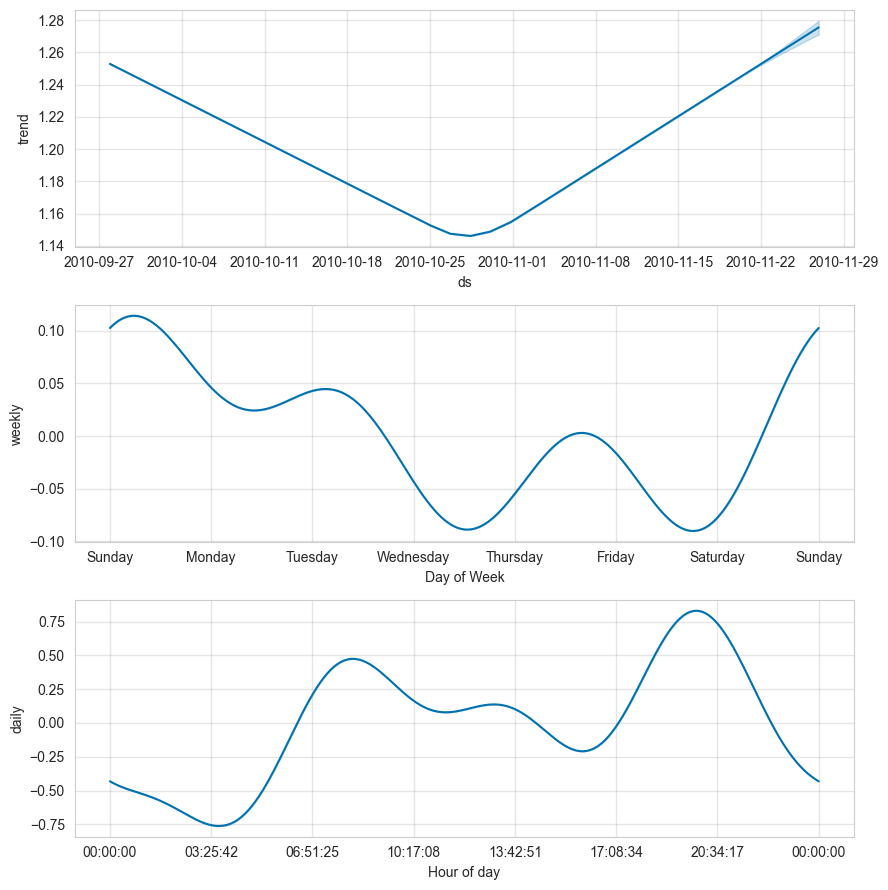

In [14]:
fig = model_prophet.plot_components(forecast)
plt.show()

Prophet's component plots reveal the daily and weekly seasonality it
learned automatically — the daily component confirms the morning/evening
peaks we saw earlier in the EDA, and the weekly component shows how usage
shifts between weekdays and weekends.